In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import lightgbm as lgb

In [6]:
# נתיב אבסולוטי (תמיד עובד)
file_path = "/home/framg/dev/anomalitor/data/nasa/processed/set1_features.csv"
df = pd.read_csv(file_path)

print(f"Shape: {df.shape}")
print(df.head())
print(df.tail())

Shape: (2156, 4)
             timestamp    rms_b1    rms_b3     ratio
0  2003.10.22.12.06.24  0.124614  0.128887  1.034292
1  2003.10.22.12.09.13  0.123811  0.129562  1.046449
2  2003.10.22.12.14.13  0.125246  0.131339  1.048644
3  2003.10.22.12.19.13  0.125197  0.131083  1.047008
4  2003.10.22.12.24.13  0.125618  0.131307  1.045290
                timestamp    rms_b1    rms_b3     ratio
2151  2003.11.25.16.07.32  0.168639  0.275645  1.634525
2152  2003.11.25.23.13.21  0.174975  0.496173  2.835683
2153  2003.11.25.23.19.56  0.174571  0.531569  3.045006
2154  2003.11.25.23.29.56  0.173471  0.474447  2.735017
2155  2003.11.25.23.39.56  0.174181  0.593610  3.407998


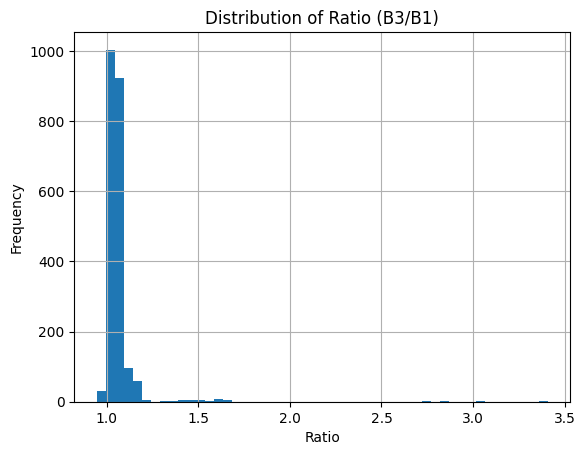

In [7]:
import matplotlib.pyplot as plt
df['ratio'].hist(bins=50)
plt.title('Distribution of Ratio (B3/B1)')
plt.xlabel('Ratio')
plt.ylabel('Frequency')
plt.show()

In [3]:
# חלוקה לשלושה שלבים לפי ה-ratio (יחס B3/B1)
def assign_stage(ratio):
    if ratio < 1.2:
        return 0  # Healthy
    elif ratio < 2.0:
        return 1  # Early degradation
    else:
        return 2  # Failure

df['stage'] = df['ratio'].apply(assign_stage)

print(df['stage'].value_counts())
print(df.head())

stage
0    2116
1      36
2       4
Name: count, dtype: int64
             timestamp    rms_b1    rms_b3     ratio  stage
0  2003.10.22.12.06.24  0.124614  0.128887  1.034292      0
1  2003.10.22.12.09.13  0.123811  0.129562  1.046449      0
2  2003.10.22.12.14.13  0.125246  0.131339  1.048644      0
3  2003.10.22.12.19.13  0.125197  0.131083  1.047008      0
4  2003.10.22.12.24.13  0.125618  0.131307  1.045290      0


In [4]:
# פיצ'רים: rms_b1, rms_b3, ratio
X = df[['rms_b1', 'rms_b3', 'ratio']]
y = df['stage']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (2156, 3)
y shape: (2156,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 1724
Test size: 432


In [6]:
rf = RandomForestClassifier(n_estimators=25, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.9954
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       424
           1       0.78      1.00      0.88         7
           2       1.00      1.00      1.00         1

    accuracy                           1.00       432
   macro avg       0.93      1.00      0.96       432
weighted avg       1.00      1.00      1.00       432



In [7]:
mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("=== MLP (Neural Network) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}")
print(classification_report(y_test, y_pred_mlp))

=== MLP (Neural Network) ===
Accuracy: 0.9931
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       424
           1       0.83      0.71      0.77         7
           2       0.00      0.00      0.00         1

    accuracy                           0.99       432
   macro avg       0.61      0.57      0.59       432
weighted avg       0.99      0.99      0.99       432



/home/framg/dev/anomalitor/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/framg/dev/anomalitor/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/framg/dev/anomalitor/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [8]:
xgb_model = xgb.XGBClassifier(n_estimators=25, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

=== XGBoost ===
Accuracy: 0.9907
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       424
           1       0.67      0.86      0.75         7
           2       0.00      0.00      0.00         1

    accuracy                           0.99       432
   macro avg       0.55      0.62      0.58       432
weighted avg       0.99      0.99      0.99       432



/home/framg/dev/anomalitor/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/framg/dev/anomalitor/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/framg/dev/anomalitor/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [9]:
lgb_model = lgb.LGBMClassifier(n_estimators=25, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

print("=== LightGBM ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgb):.4f}")
print(classification_report(y_test, y_pred_lgb))

=== LightGBM ===
Accuracy: 0.9931
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       424
           1       0.75      0.86      0.80         7
           2       1.00      1.00      1.00         1

    accuracy                           0.99       432
   macro avg       0.92      0.95      0.93       432
weighted avg       0.99      0.99      0.99       432



In [10]:
results = {
    'Model': ['Random Forest', 'MLP', 'XGBoost', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgb)
    ]
}

results_df = pd.DataFrame(results)
print(results_df.sort_values('Accuracy', ascending=False))

           Model  Accuracy
0  Random Forest  0.995370
1            MLP  0.993056
3       LightGBM  0.993056
2        XGBoost  0.990741


In [11]:
# בחר את המודל עם ה-Accuracy הכי גבוה
best_model = rf  # שנה לפי התוצאות
y_pred_best = y_pred_rf

print("=== Confusion Matrix - Best Model ===")
print(confusion_matrix(y_test, y_pred_best))

=== Confusion Matrix - Best Model ===
[[422   2   0]
 [  0   7   0]
 [  0   0   1]]
